# Logistic Regression Model

### Step 1: Importing all the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

pd.set_option('display.max_columns', None)

### Step 2: Data Loading

In [2]:
df = pd.read_csv("Earthquake.csv")

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Dataset shape: (17100, 22)

First 5 rows:
                       time  latitude  longitude    depth  mag magType    nst  \
0  2026-05-30T21:15:59.807Z   38.3564    73.8219  131.794  4.9      mb   80.0   
1  2026-05-29T12:22:54.128Z   23.4621    93.7220   57.374  4.3      mb   32.0   
2  2026-05-28T02:37:50.460Z   33.1393    96.1517   10.000  4.7      mb  111.0   
3  2026-05-26T16:30:57.714Z   23.1849    94.5425  102.712  4.3      mb   21.0   
4  2026-05-26T14:07:51.354Z   23.7982    94.8304  112.776  4.5      mb   36.0   

     gap   dmin   rms net          id                   updated  \
0   78.0  1.052  0.94  us  us7000spkb  2026-05-30T21:35:21.040Z   
1  126.0  2.503  0.68  us  us7000sp9a  2026-05-29T12:58:49.040Z   
2   47.0  5.492  0.73  us  us7000snzw  2026-05-28T05:26:32.040Z   
3  158.0  2.000  0.43  us  us7000sntk  2026-05-27T14:59:41.040Z   
4   68.0  2.581  0.40  us  us6000t08d  2026-05-26T17:07:05.040Z   

                                   place        type  horizontalErro

### Step 3: Preprocessing

Following the module's required pipeline order (Data Collection -> Preprocessing -> Feature Engineering -> Model Training), and using the exact same cleaning steps as our team's Decision Tree and Random Forest notebooks, so all three classifiers start from an identical, consistent dataset.


In [3]:
print("Rows before filtering to earthquakes only:", df.shape[0])
df = df[df["type"] == "earthquake"].copy()
print("Rows after removing non-earthquake events (e.g. nuclear explosions):", df.shape[0])

feature_cols = ["latitude", "longitude", "depth", "gap", "dmin", "rms", "nst", "horizontalError", "depthError"]

print("\nMissing values in candidate features:")
print(df[feature_cols].isnull().sum())

# Median imputation: robust to outliers, avoids dropping the majority of rows
# that columns like 'dmin' and 'horizontalError' would otherwise cost us.
X = df[feature_cols].copy()
for col in feature_cols:
    X[col] = X[col].fillna(X[col].median())

print("\nMissing values after imputation:", X.isnull().sum().sum())

Rows before filtering to earthquakes only: 17100
Rows after removing non-earthquake events (e.g. nuclear explosions): 17097

Missing values in candidate features:
latitude               0
longitude              0
depth                  0
gap                 6655
dmin               10861
rms                  256
nst                 9878
horizontalError    11345
depthError          6902
dtype: int64

Missing values after imputation: 0


### Step 4: Feature Engineering

#### **Target variable — identical definition to Decision Tree and Random Forest.** We reuse the exact same bins and labels used for our team's other two classifiers, so that all three models can be fairly compared in Section 5 of the group report.

#### **Feature scaling — needed here, unlike for the tree-based models.** Decision Tree and Random Forest split on one feature at a time, so the numeric scale of each feature does not affect them. Logistic Regression, however, computes a weighted *sum* across all features at once (Step above), so a feature with a naturally larger numeric range, such as `depth` (up to ~400) compared with `latitude` (only a few tens of degrees), would unfairly dominate the model's decision purely because of its scale, not because it is more informative. We correct this using `StandardScaler`, which rescales every feature to have a mean of 0 and a standard deviation of 1.

In [12]:
bins = [0, 4.5, 5.5, 10]
labels = ["Light", "Moderate", "Strong"]
df["Risk_class"] = pd.cut(df["mag"], bins=bins, labels=labels)

print("Risk class distribution:")
print(df["Risk_class"].value_counts())

y = df["Risk_class"]

# Defensive check: drop any rows where the target could not be computed.
mask = y.notna()
X, y = X.loc[mask], y[mask]

# not required for the tree-based models used elsewhere in this project.
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

print("\nFeatures before scaling (first 3 rows):")
print(X.head(3))
print("\nFeatures after scaling (first 3 rows):")
print(X_scaled.head(3))

Severity class distribution:
severity_class
Light       9574
Moderate    7036
Strong       487
Name: count, dtype: int64

Features before scaling (first 3 rows):
   latitude  longitude    depth    gap   dmin   rms    nst  horizontalError  \
0   38.3564    73.8219  131.794   78.0  1.052  0.94   80.0             7.07   
1   23.4621    93.7220   57.374  126.0  2.503  0.68   32.0            10.75   
2   33.1393    96.1517   10.000   47.0  5.492  0.73  111.0             8.19   

   depthError  
0       6.645  
1       7.066  
2       1.856  

Features after scaling (first 3 rows):
   latitude  longitude     depth       gap      dmin       rms       nst  \
0  0.989654  -0.509981  1.127846 -0.348015 -0.939687  0.048819  0.593703   
1 -1.599646   1.339875 -0.058390  1.006911  0.049427 -0.941417 -0.391800   
2  0.082687   1.565733 -0.813520 -1.223071  2.086961 -0.750987  1.230174   

   horizontalError  depthError  
0        -0.052077   -0.087446  
1         2.887621   -0.005174  
2         0.8

### Step 5: Train-Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape, " Test size:", X_test.shape)
print("\nClass balance preserved in test set:")
print(y_test.value_counts(normalize=True).round(3))

Train size: (13677, 9)  Test size: (3420, 9)

Class balance preserved in test set:
severity_class
Minor       0.560
Moderate    0.412
Strong      0.028
Name: proportion, dtype: float64


### Step 6: Model Training

### Hyperparameter choices

 #### `solver="lbfgs"` — the standard optimiser for Logistic Regression in scikit-learn. With four target classes, `lbfgs` automatically applies the multinomial (softmax) formulation described in the theory section above — modern scikit-learn versions (1.5+) no longer accept an explicit `multi_class` argument, since this is now handled automatically based on the solver and the number of classes.
 #### `max_iter=1000` — increased from the default (100) to give the optimiser enough iterations to properly converge on this dataset.
 #### `class_weight="balanced"` — automatically re-weights each class in inverse proportion to its frequency, exactly as in our team's Decision Tree and Random Forest, so all three models handle the same class imbalance under the same conditions.

In [6]:
logreg_model = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
    class_weight="balanced",
    random_state=42,
)
logreg_model.fit(X_train, y_train)

y_pred = logreg_model.predict(X_test)
print("Model trained. Predictions generated for", len(y_pred), "test samples.")

Model trained. Predictions generated for 3420 test samples.


### Step 7: Evaluation Metrics

####  The same four classification metrics as our team's Decision Tree and Random Forest, computed the same way (weighted averaging, to reflect the class imbalance honestly while the full per-class breakdown below still shows the rare "Strong" class on its own).

In [7]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print("=== Logistic Regression Performance ===")
print(f"Accuracy          : {accuracy:.4f}")
print(f"Precision (wtd)   : {precision:.4f}")
print(f"Recall (wtd)      : {recall:.4f}")
print(f"F1-score (wtd)    : {f1:.4f}")

print("\nFull per-class classification report:")
print(classification_report(y_test, y_pred, zero_division=0))

=== Logistic Regression Performance ===
Accuracy          : 0.5725
Precision (wtd)   : 0.6512
Recall (wtd)      : 0.5725
F1-score (wtd)    : 0.6037

Full per-class classification report:
              precision    recall  f1-score   support

       Minor       0.75      0.62      0.68      1915
    Moderate       0.55      0.51      0.53      1408
      Strong       0.10      0.54      0.16        97

    accuracy                           0.57      3420
   macro avg       0.47      0.56      0.46      3420
weighted avg       0.65      0.57      0.60      3420




### Step 8: Confusion Matrix


Confusion Matrix (rows = actual, columns = predicted):
          Minor  Moderate  Strong
Minor      1193       543     179
Moderate    383       713     312
Strong       11        34      52


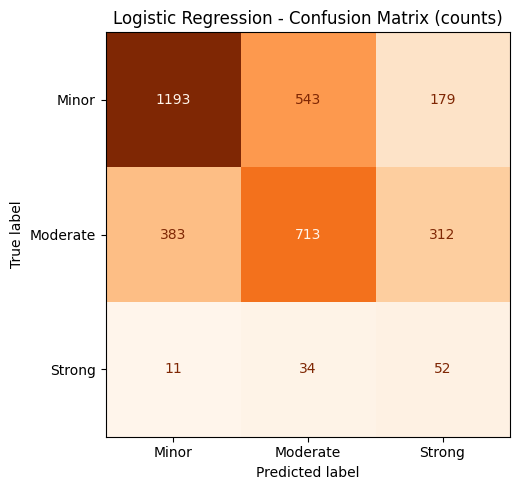

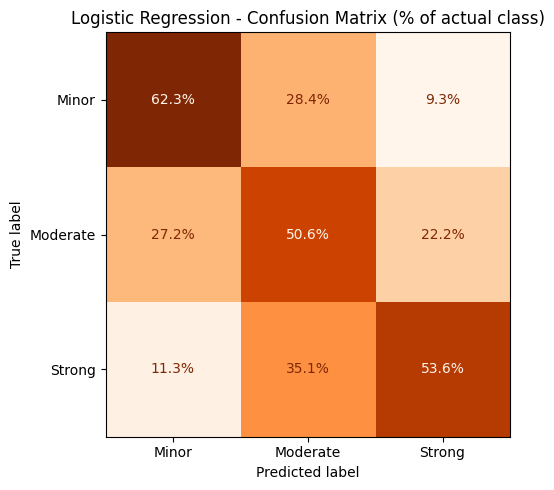

In [11]:
labels = ["Light", "Moderate", "Strong"]

cm = confusion_matrix(y_test, y_pred, labels=labels)
print("Confusion Matrix (rows = actual, columns = predicted):")
print(pd.DataFrame(cm, index=labels, columns=labels))

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap="Oranges", colorbar=False)
plt.title("Logistic Regression - Confusion Matrix (counts)")
plt.tight_layout()
plt.savefig("logistic_regression_confusion_matrix.png", dpi=150)
plt.show()

cm_pct = confusion_matrix(y_test, y_pred, labels=labels, normalize="true")

fig, ax = plt.subplots(figsize=(6, 5))
disp_pct = ConfusionMatrixDisplay(confusion_matrix=cm_pct, display_labels=labels)
disp_pct.plot(ax=ax, cmap="Oranges", colorbar=False, values_format=".1%")
plt.title("Logistic Regression - Confusion Matrix (% of actual class)")
plt.tight_layout()
plt.savefig("logistic_regression_confusion_matrix_pct.png", dpi=150)
plt.show()

### Step 9: Coefficient Interpretation

#### Unlike Decision Tree and Random Forest, which produce a `feature_importances_` ranking, Logistic Regression gives us a **signed coefficient for every feature, for every class**. The sign tells us the *direction* of the relationship (positive means higher values of that feature push the prediction toward this class), and the magnitude tells us the *strength* of that relationship, since all features were scaled to the same range in Step 4, making the coefficients directly comparable to one another.

Logistic Regression coefficients (rows = class, columns = feature):
          latitude  longitude  depth    gap   dmin    rms    nst  \
Minor        0.134      0.006  0.053  0.594  0.045 -0.277 -0.852   
Moderate     0.045      0.049 -0.173 -0.065  0.002 -0.128  0.275   
Strong      -0.179     -0.055  0.121 -0.529 -0.048  0.405  0.578   

          horizontalError  depthError  
Minor              -0.010       0.264  
Moderate            0.009       0.306  
Strong              0.001      -0.570  


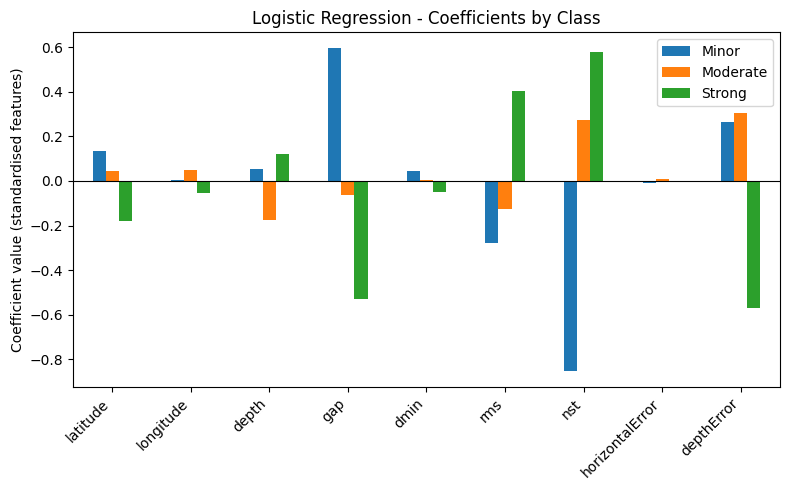

In [9]:
coef_df = pd.DataFrame(
    logreg_model.coef_,
    columns=feature_cols,
    index=logreg_model.classes_,
)
print("Logistic Regression coefficients (rows = class, columns = feature):")
print(coef_df.round(3))

fig, ax = plt.subplots(figsize=(8, 5))
coef_df.T.plot(kind="bar", ax=ax)
ax.set_title("Logistic Regression - Coefficients by Class")
ax.set_ylabel("Coefficient value (standardised features)")
ax.axhline(0, color="black", linewidth=0.8)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("logistic_regression_coefficients.png", dpi=150)
plt.show()

### Step 10: Prediction on New Examples

Now, let's demonstrate how to use the trained `logreg_model` to predict the `severity_class` for new, unseen earthquake examples. It's important to apply the same `StandardScaler` that was used during training to these new examples.

In [10]:


# Create some synthetic new examples with the same feature columns
# The values should be within a reasonable range for each feature.
new_examples_data = {
    "latitude": [35.0, 40.0, 20.0],
    "longitude": [70.0, 80.0, 90.0],
    "depth": [10.0, 150.0, 50.0],
    "gap": [60.0, 100.0, 80.0],
    "dmin": [0.5, 3.0, 1.5],
    "rms": [0.2, 1.0, 0.7],
    "nst": [50.0, 150.0, 90.0],
    "horizontalError": [5.0, 12.0, 8.0],
    "depthError": [3.0, 8.0, 5.0]
}

new_examples_df = pd.DataFrame(new_examples_data)

print("New unscaled examples:")
display(new_examples_df)

# Scale the new examples using the SAME scaler fitted on the training data
# This is crucial for consistent prediction.
new_examples_scaled = pd.DataFrame(
    scaler.transform(new_examples_df), # Use transform, not fit_transform
    columns=new_examples_df.columns
)

print("\nNew scaled examples:")
display(new_examples_scaled)

# Make predictions
new_predictions = logreg_model.predict(new_examples_scaled)

print("\nPredictions for new examples:")
for i, pred in enumerate(new_predictions):
    print(f"Example {i+1}: Predicted Severity Class = {pred}")

New unscaled examples:


,latitude,longitude,depth,gap,dmin,rms,nst,horizontalError,depthError
0,35.0,70.0,10.0,60.0,0.5,0.2,50.0,5.0,3.0
1,40.0,80.0,150.0,100.0,3.0,1.0,150.0,12.0,8.0
2,20.0,90.0,50.0,80.0,1.5,0.7,90.0,8.0,5.0



New scaled examples:


,latitude,longitude,depth,gap,dmin,rms,nst,horizontalError,depthError
0,0.406160,-0.865253,-0.813520,-0.856112,-1.315973,-2.769544,-0.022237,-1.705657,-0.799752
1,1.275385,0.064318,1.418045,0.272993,0.388221,0.277335,2.030896,3.886160,0.177348
2,-2.201515,0.993889,-0.175930,-0.291559,-0.634296,-0.865245,0.799017,0.690836,-0.408912



Predictions for new examples:
Example 1: Predicted Severity Class = Moderate
Example 2: Predicted Severity Class = Moderate
Example 3: Predicted Severity Class = Moderate
